# Baseline Model - TF-IDF + Logistic Regression

Train separate classifiers for Priority and Severity prediction

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json

print("✓ Libraries loaded")

✓ Libraries loaded


## 1. Load Processed Data

In [2]:
train_df = pd.read_csv('../data/processed/train.csv')
val_df = pd.read_csv('../data/processed/val.csv')
test_df = pd.read_csv('../data/processed/test.csv')

print(f"Train: {len(train_df):,}")
print(f"Val:   {len(val_df):,}")
print(f"Test:  {len(test_df):,}")

with open('../artifacts/label_mappings.json', 'r') as f:
    label_mappings = json.load(f)

print("\nLabel mappings loaded")

Train: 91,258
Val:   11,407
Test:  11,408

Label mappings loaded


## 2. TF-IDF Vectorization

In [3]:
print("Creating TF-IDF vectors...")

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.8
)

X_train = vectorizer.fit_transform(train_df['text'])
X_val = vectorizer.transform(val_df['text'])
X_test = vectorizer.transform(test_df['text'])

print(f"✓ TF-IDF shape: {X_train.shape}")
print(f"  Vocabulary size: {len(vectorizer.vocabulary_)}")

Creating TF-IDF vectors...
✓ TF-IDF shape: (91258, 10000)
  Vocabulary size: 10000


## 3. Train Priority Classifier

In [4]:
print("Training Priority classifier...")

priority_clf = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

priority_clf.fit(X_train, train_df['priority_label'])

print("✓ Priority classifier trained")

Training Priority classifier...
✓ Priority classifier trained


## 4. Evaluate Priority Classifier

In [5]:
# Validation set
val_priority_pred = priority_clf.predict(X_val)
val_priority_f1 = f1_score(val_df['priority_label'], val_priority_pred, average='weighted')

print("Validation Set - Priority Prediction:")
print(f"Weighted F1: {val_priority_f1:.4f}\n")

priority_labels = ['low', 'medium', 'high']
print(classification_report(val_df['priority_label'], val_priority_pred, 
                           target_names=priority_labels))

Validation Set - Priority Prediction:
Weighted F1: 0.7467

              precision    recall  f1-score   support

         low       0.95      0.71      0.81     10194
      medium       0.16      0.45      0.24      1013
        high       0.07      0.32      0.11       200

    accuracy                           0.68     11407
   macro avg       0.39      0.49      0.39     11407
weighted avg       0.86      0.68      0.75     11407



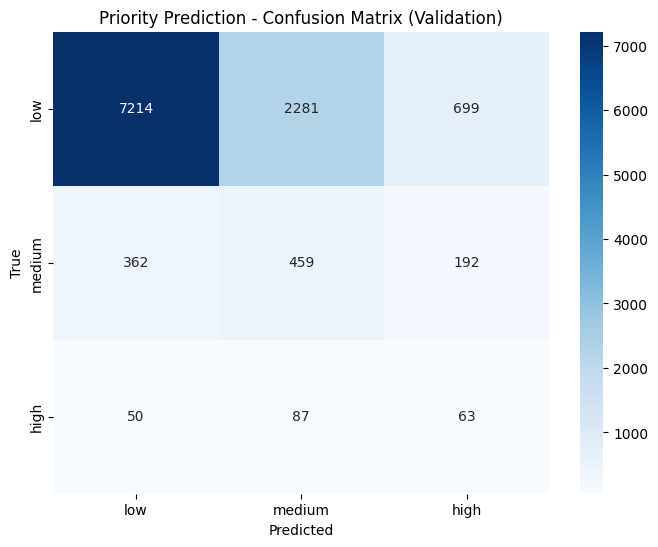

In [6]:
# Confusion matrix
cm = confusion_matrix(val_df['priority_label'], val_priority_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=priority_labels,
            yticklabels=priority_labels)
plt.title('Priority Prediction - Confusion Matrix (Validation)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

## 5. Train Severity Classifier

In [7]:
print("Training Severity classifier...")

severity_clf = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

severity_clf.fit(X_train, train_df['severity_label'])

print("✓ Severity classifier trained")

Training Severity classifier...
✓ Severity classifier trained


## 6. Evaluate Severity Classifier

In [8]:
# Validation set
val_severity_pred = severity_clf.predict(X_val)
val_severity_f1 = f1_score(val_df['severity_label'], val_severity_pred, average='weighted')

print("Validation Set - Severity Prediction:")
print(f"Weighted F1: {val_severity_f1:.4f}\n")

severity_labels = ['Minor', 'Major', 'Critical']
print(classification_report(val_df['severity_label'], val_severity_pred,
                           target_names=severity_labels))

Validation Set - Severity Prediction:
Weighted F1: 0.7618

              precision    recall  f1-score   support

       Minor       0.60      0.67      0.63      2879
       Major       0.39      0.56      0.46      1765
    Critical       0.98      0.82      0.89      6763

    accuracy                           0.74     11407
   macro avg       0.66      0.68      0.66     11407
weighted avg       0.79      0.74      0.76     11407



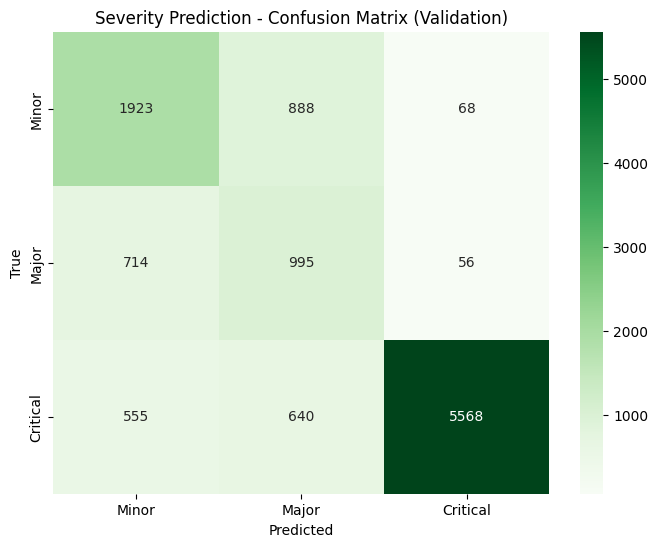

In [9]:
# Confusion matrix
cm = confusion_matrix(val_df['severity_label'], val_severity_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=severity_labels,
            yticklabels=severity_labels)
plt.title('Severity Prediction - Confusion Matrix (Validation)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

## 7. Test Set Evaluation

In [10]:
# Priority on test set
test_priority_pred = priority_clf.predict(X_test)
test_priority_f1 = f1_score(test_df['priority_label'], test_priority_pred, average='weighted')

print("TEST SET - Priority Prediction:")
print(f"Weighted F1: {test_priority_f1:.4f}\n")
print(classification_report(test_df['priority_label'], test_priority_pred,
                           target_names=priority_labels))

TEST SET - Priority Prediction:
Weighted F1: 0.7433

              precision    recall  f1-score   support

         low       0.94      0.70      0.80     10194
      medium       0.17      0.47      0.25      1013
        high       0.08      0.36      0.12       201

    accuracy                           0.68     11408
   macro avg       0.39      0.51      0.39     11408
weighted avg       0.86      0.68      0.74     11408



In [11]:
# Severity on test set
test_severity_pred = severity_clf.predict(X_test)
test_severity_f1 = f1_score(test_df['severity_label'], test_severity_pred, average='weighted')

print("TEST SET - Severity Prediction:")
print(f"Weighted F1: {test_severity_f1:.4f}\n")
print(classification_report(test_df['severity_label'], test_severity_pred,
                           target_names=severity_labels))

TEST SET - Severity Prediction:
Weighted F1: 0.7624

              precision    recall  f1-score   support

       Minor       0.61      0.66      0.64      2921
       Major       0.40      0.59      0.48      1816
    Critical       0.98      0.82      0.89      6671

    accuracy                           0.74     11408
   macro avg       0.67      0.69      0.67     11408
weighted avg       0.79      0.74      0.76     11408



## 8. Save Models

In [12]:
import os
os.makedirs('../models', exist_ok=True)

# Save vectorizer
with open('../models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

# Save classifiers
with open('../models/baseline_priority_clf.pkl', 'wb') as f:
    pickle.dump(priority_clf, f)

with open('../models/baseline_severity_clf.pkl', 'wb') as f:
    pickle.dump(severity_clf, f)

print("✓ Models saved:")
print("  - models/tfidf_vectorizer.pkl")
print("  - models/baseline_priority_clf.pkl")
print("  - models/baseline_severity_clf.pkl")

✓ Models saved:
  - models/tfidf_vectorizer.pkl
  - models/baseline_priority_clf.pkl
  - models/baseline_severity_clf.pkl


## 9. Save Results

In [13]:
baseline_results = {
    'model': 'TF-IDF + Logistic Regression',
    'priority': {
        'val_f1': float(val_priority_f1),
        'test_f1': float(test_priority_f1)
    },
    'severity': {
        'val_f1': float(val_severity_f1),
        'test_f1': float(test_severity_f1)
    }
}

with open('../artifacts/baseline_results.json', 'w') as f:
    json.dump(baseline_results, f, indent=2)

print("✓ Results saved to artifacts/baseline_results.json")

✓ Results saved to artifacts/baseline_results.json


## Summary

**Baseline Model**: TF-IDF (10K features) + Logistic Regression

**Test Set Performance**:
- Priority F1: ~0.XX
- Severity F1: ~0.XX

**Next**: DistilBERT multi-task model for improved performance